# NCAA Men's March Madness Factor Importance

This notebook studies how the Four Factors and miscellaneous team stats affect NCAA men's tournament predictions. It compares several model families, calibrates probabilities, and measures importance on held-out seasons.

Requested split:

- Training: 1997-2016
- Validation: 2017-2025

Timing note: KenPom's season-only historical pages are end-of-season snapshots, so the original KenPom decision tree below is retained only as a legacy benchmark. The primary analysis in section 9 computes KenPom-compatible Four Factors and misc rates exclusively from regular-season detailed box scores. That source is confirmed pre-tournament and does not include tournament games.

In [1]:
from pathlib import Path
import json
import os
import sys

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.download_ncaa_data import main as download_ncaa_data
from src.kenpom_scraper import combine_cached_years, scrape_year, KenPomClient
from src.train_decision_tree import (
    load_tournament_games,
    load_kenpom_features,
    numeric_feature_columns,
    attach_features,
    build_examples,
    evaluate,
)

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
MODEL_PATH = PROJECT_ROOT / 'models' / 'decision_tree_march_madness.joblib'
PREDICTIONS_PATH = PROJECT_ROOT / 'reports' / 'validation_predictions.csv'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'metrics.json'

PROJECT_ROOT

PosixPath('/Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning')

## 1. Download NCAA Tournament Results

The analysis expects Kaggle-format team, tournament, seed, and detailed regular-season files.

In [2]:
needed_ncaa_files = [
    RAW_DIR / 'MTeams.csv',
    RAW_DIR / 'MNCAATourneyCompactResults.csv',
    RAW_DIR / 'MNCAATourneySeeds.csv',
    RAW_DIR / 'MRegularSeasonDetailedResults.csv',
]
if not all(path.exists() for path in needed_ncaa_files):
    download_ncaa_data()
else:
    print('NCAA files already exist:', [path.name for path in needed_ncaa_files])

NCAA files already exist: ['MTeams.csv', 'MNCAATourneyCompactResults.csv', 'MNCAATourneySeeds.csv', 'MRegularSeasonDetailedResults.csv']


## 2. Legacy KenPom Benchmark Data

This optional benchmark uses the historical KenPom pages. Those season-only pages contain season-end values and are not used for the trustworthy feature-importance conclusions in section 9.

Set `RUN_KENPOM_SCRAPE = True` to refresh missing seasons. If `KENPOM_EMAIL` and `KENPOM_PASSWORD` are available in the environment, the scraper also attempts subscriber Four Factors and Miscellaneous pages. Without credentials, it uses public efficiency ratings only.

Recommended credential handling from a terminal before launching Jupyter:

```bash
export KENPOM_EMAIL='your-email'
export KENPOM_PASSWORD='your-password'
jupyter notebook
```

In [3]:
START_YEAR = 2002
END_YEAR = 2025
RUN_KENPOM_SCRAPE = False
SCRAPE_DELAY_SECONDS = 10.0

has_kenpom_login = bool(os.getenv('KENPOM_EMAIL') and os.getenv('KENPOM_PASSWORD'))
public_efficiency_only = not has_kenpom_login

if RUN_KENPOM_SCRAPE:
    client = KenPomClient(os.getenv('KENPOM_EMAIL'), os.getenv('KENPOM_PASSWORD'), delay=SCRAPE_DELAY_SECONDS)
    client.login()
    for year in range(START_YEAR, END_YEAR + 1):
        print(f'Scraping KenPom {year}')
        scrape_year(
            client,
            year,
            include_team_pages=has_kenpom_login,
            public_efficiency_only=public_efficiency_only,
            use_cache=True,
        )

kenpom = combine_cached_years(START_YEAR, END_YEAR)
print(kenpom.shape)
kenpom.head()

Wrote data/processed/kenpom_team_features.csv with 8,314 rows
(8314, 77)


,season,team_x,team_norm,eff_rk,eff_conf,eff_wl,eff_netrtg,eff_ortg,eff_ortg_rank,eff_drtg,...,misc_threep,misc_threep_rank,misc_twop,misc_twop_rank,misc_twop_dist,misc_twop_dist_rank,misc_assist,misc_assist_rank,misc_threepa,misc_threepa_rank
0,2002,Air Force,air force,181.0,MWC,9-19,-1.64,103.8,149.0,105.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,Akron,akron,227.0,MAC,9-21,-5.94,105.2,130.0,111.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,Alabama,alabama,22.0,SEC,27-8,18.73,114.0,24.0,95.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002,Alabama A&M,alabama a&m,262.0,SWAC,17-10,-9.53,92.2,304.0,101.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002,Alabama St.,alabama st.,272.0,SWAC,18-12,-12.62,90.1,312.0,102.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Build Matchup-Level Training Rows

Each tournament game becomes two examples: winner-vs-loser labeled `1`, and loser-vs-winner labeled `0`. For every numeric KenPom feature, the model gets both the signed feature difference and the absolute difference.

In [4]:
games = load_tournament_games()
kenpom = load_kenpom_features()
feature_cols = numeric_feature_columns(kenpom)

games_with_features = attach_features(games, kenpom, feature_cols)
x, y, meta = build_examples(games_with_features, feature_cols)

train_mask = meta['season'].between(1997, 2016)
valid_mask = meta['season'].between(2017, 2025)

observed_train_cols = x.loc[train_mask].notna().any(axis=0)
x = x.loc[:, observed_train_cols]

summary = {
    'feature_count': len(feature_cols),
    'model_column_count': x.shape[1],
    'all_examples': int(len(x)),
    'train_examples': int(train_mask.sum()),
    'validation_examples': int(valid_mask.sum()),
    'actual_train_years': sorted(meta.loc[train_mask, 'season'].unique().tolist()),
    'actual_validation_years': sorted(meta.loc[valid_mask, 'season'].unique().tolist()),
}
summary

{'feature_count': 67,
 'model_column_count': 114,
 'all_examples': 2346,
 'train_examples': 1658,
 'validation_examples': 688,
 'actual_train_years': [2002,
  2003,
  2004,
  2005,
  2006,
  2007,
  2008,
  2009,
  2010,
  2011,
  2012,
  2013,
  2014,
  2015,
  2016],
 'actual_validation_years': [2017, 2018, 2019, 2021, 2022, 2023]}

## 4. Train Decision Tree Model

In [5]:
if train_mask.sum() == 0 or valid_mask.sum() == 0:
    raise ValueError('No train or validation rows after joining tournament games to KenPom features.')

model = Pipeline(
    steps=[
        ('imputer', ColumnTransformer([('num', SimpleImputer(strategy='median'), x.columns)], remainder='drop')),
        (
            'tree',
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_leaf=25,
                criterion='log_loss',
                random_state=42,
            ),
        ),
    ]
)

model.fit(x.loc[train_mask], y.loc[train_mask])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matric

## 5. Evaluate On Validation Seasons

In [6]:
train_metrics = evaluate(model, x.loc[train_mask], y.loc[train_mask])
valid_metrics = evaluate(model, x.loc[valid_mask], y.loc[valid_mask])

metrics = {
    'requested_train_years': '1997-2016',
    'requested_validation_years': '2017-2025',
    'actual_train_years': summary['actual_train_years'],
    'actual_validation_years': summary['actual_validation_years'],
    'rows': {
        'train': int(train_mask.sum()),
        'validation': int(valid_mask.sum()),
        'all_examples': int(len(x)),
    },
    'metrics': {'train': train_metrics, 'validation': valid_metrics},
}

pd.DataFrame(metrics['metrics']).T

,accuracy,brier,log_loss,roc_auc
train,0.766586,0.154396,0.459145,0.854320
validation,0.718023,0.177255,0.908892,0.814025


## 6. Inspect The Tree And Feature Importance

In [7]:
tree_text = export_text(model.named_steps['tree'], feature_names=list(x.columns))
print(tree_text)

|--- eff_rk_diff <= -2.50
|   |--- eff_netrtg_abs_diff <= 7.88
|   |   |--- eff_luck_diff <= -0.02
|   |   |   |--- eff_sos_ortg_abs_diff <= 0.95
|   |   |   |   |--- class: 0
|   |   |   |--- eff_sos_ortg_abs_diff >  0.95
|   |   |   |   |--- class: 1
|   |   |--- eff_luck_diff >  -0.02
|   |   |   |--- misc_a_diff <= -7.85
|   |   |   |   |--- class: 1
|   |   |   |--- misc_a_diff >  -7.85
|   |   |   |   |--- class: 1
|   |--- eff_netrtg_abs_diff >  7.88
|   |   |--- eff_drtg_rank_diff <= -125.00
|   |   |   |--- class: 1
|   |   |--- eff_drtg_rank_diff >  -125.00
|   |   |   |--- misc_stl_rank_diff <= -139.00
|   |   |   |   |--- class: 1
|   |   |   |--- misc_stl_rank_diff >  -139.00
|   |   |   |   |--- class: 1
|--- eff_rk_diff >  -2.50
|   |--- eff_netrtg_abs_diff <= 7.88
|   |   |--- eff_luck_rank_diff <= 107.50
|   |   |   |--- eff_netrtg_diff <= -3.48
|   |   |   |   |--- class: 0
|   |   |   |--- eff_netrtg_diff >  -3.48
|   |   |   |   |--- class: 1
|   |   |--- eff_luck_r

In [8]:
importance = pd.DataFrame(
    {
        'feature': x.columns,
        'importance': model.named_steps['tree'].feature_importances_,
    }
).sort_values('importance', ascending=False)

importance.query('importance > 0').head(20)

,feature,importance
0,eff_rk_diff,0.573228
3,eff_netrtg_abs_diff,0.224031
18,eff_luck_rank_diff,0.037038
96,misc_stl_rank_diff,0.035020
2,eff_netrtg_diff,0.023126
16,eff_luck_diff,0.022970
11,eff_drtg_rank_abs_diff,0.019343
10,eff_drtg_rank_diff,0.019343
34,eff_ncsos_netrtg_rank_diff,0.017311
102,misc_a_diff,0.017148


## 7. Run 2026 Tournament Predictions

In [9]:
from src.predict_2026_tournament import main as predict_2026_tournament

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({'model': model, 'features': list(x.columns)}, MODEL_PATH)
predict_2026_tournament()

summary_2026 = json.loads((PROJECT_ROOT / 'reports' / '2026_tournament_summary.json').read_text())
predictions_2026 = pd.read_csv(PROJECT_ROOT / 'reports' / '2026_tournament_predictions.csv')

pd.DataFrame(summary_2026['by_round']).T

{
  "season": 2026,
  "games": 67,
  "correct": 58,
  "accuracy": 0.8656716417910447,
  "brier": 0.1398306274329879,
  "log_loss": 0.4381540379139559,
  "roc_auc": null,
  "note": "Predictions are scored from actual-winner orientation, so ROC AUC is undefined because y_true contains only wins.",
  "by_round": {
    "Championship": {
      "sum": 1,
      "count": 1,
      "mean": 1.0
    },
    "Elite Eight": {
      "sum": 3,
      "count": 4,
      "mean": 0.75
    },
    "Final Four": {
      "sum": 1,
      "count": 2,
      "mean": 0.5
    },
    "First Four": {
      "sum": 3,
      "count": 4,
      "mean": 0.75
    },
    "First Round": {
      "sum": 30,
      "count": 32,
      "mean": 0.9375
    },
    "Second Round": {
      "sum": 14,
      "count": 16,
      "mean": 0.875
    },
    "Sweet 16": {
      "sum": 6,
      "count": 8,
      "mean": 0.75
    }
  }
}
Wrote reports/2026_tournament_predictions.csv
Wrote reports/2026_tournament_summary.json


,sum,count,mean
Championship,1.0,1.0,1.0000
Elite Eight,3.0,4.0,0.7500
Final Four,1.0,2.0,0.5000
First Four,3.0,4.0,0.7500
First Round,30.0,32.0,0.9375
Second Round,14.0,16.0,0.8750
Sweet 16,6.0,8.0,0.7500


In [10]:
predictions_2026[[
    'round',
    'winner',
    'loser',
    'winner_score',
    'loser_score',
    'pred_actual_winner_prob',
    'predicted_winner',
    'prediction_correct',
]].head(20)

,round,winner,loser,winner_score,loser_score,pred_actual_winner_prob,predicted_winner,prediction_correct
0,First Four,Howard,UMBC,86,83,0.523605,Howard,True
1,First Four,Texas,NC State,68,66,0.616541,Texas,True
2,First Four,Prairie View A&M,Lehigh,67,55,0.616541,Prairie View A&M,True
3,First Four,Miami OH,SMU,89,79,0.138393,SMU,False
4,First Round,TCU,Ohio State,66,64,0.323529,Ohio State,False
5,First Round,Nebraska,Troy,76,47,1.000000,Nebraska,True
6,First Round,Louisville,South Florida,83,79,0.710784,Louisville,True
7,First Round,High Point,Wisconsin,83,82,0.138393,Wisconsin,False
8,First Round,Duke,Siena,71,65,1.000000,Duke,True
9,First Round,Vanderbilt,McNeese,78,68,0.861607,Vanderbilt,True


In [11]:
predictions_2026.loc[
    ~predictions_2026['prediction_correct'],
    ['round', 'winner', 'loser', 'winner_score', 'loser_score', 'pred_actual_winner_prob', 'predicted_winner']
]

,round,winner,loser,winner_score,loser_score,pred_actual_winner_prob,predicted_winner
3,First Four,Miami OH,SMU,89,79,0.138393,SMU
4,First Round,TCU,Ohio State,66,64,0.323529,Ohio State
7,First Round,High Point,Wisconsin,83,82,0.138393,Wisconsin
40,Second Round,Texas,Gonzaga,74,68,0.022727,Gonzaga
48,Second Round,Iowa,Florida,73,72,0.138393,Florida
53,Sweet 16,Iowa,Nebraska,77,71,0.261538,Nebraska
59,Sweet 16,Tennessee,Iowa State,76,62,0.323529,Iowa State
63,Elite Eight,UConn,Duke,73,72,0.323529,Duke
64,Final Four,UConn,Illinois,71,62,0.323529,Illinois


## 8. Generated Model Visualizations

These cells create saved visual explanations for the decision tree: feature importance, round accuracy, confidence vs margin, and a bracket-style HTML report for the 2026 tournament.

In [12]:
from IPython.display import HTML, IFrame, Image, display
from src.visualize_model import main as create_model_visualizations

create_model_visualizations()

{
  "feature_importance": "reports/feature_importance.png",
  "round_accuracy": "reports/2026_accuracy_by_round.png",
  "confidence": "reports/2026_prediction_confidence.png",
  "explanations": "reports/2026_prediction_explanations.csv",
  "bracket": "reports/2026_bracket_predictions.html"
}


### Feature Importance Chart

This shows which matchup-difference features the decision tree actually used most. Higher bars mean the feature reduced impurity more across tree splits.

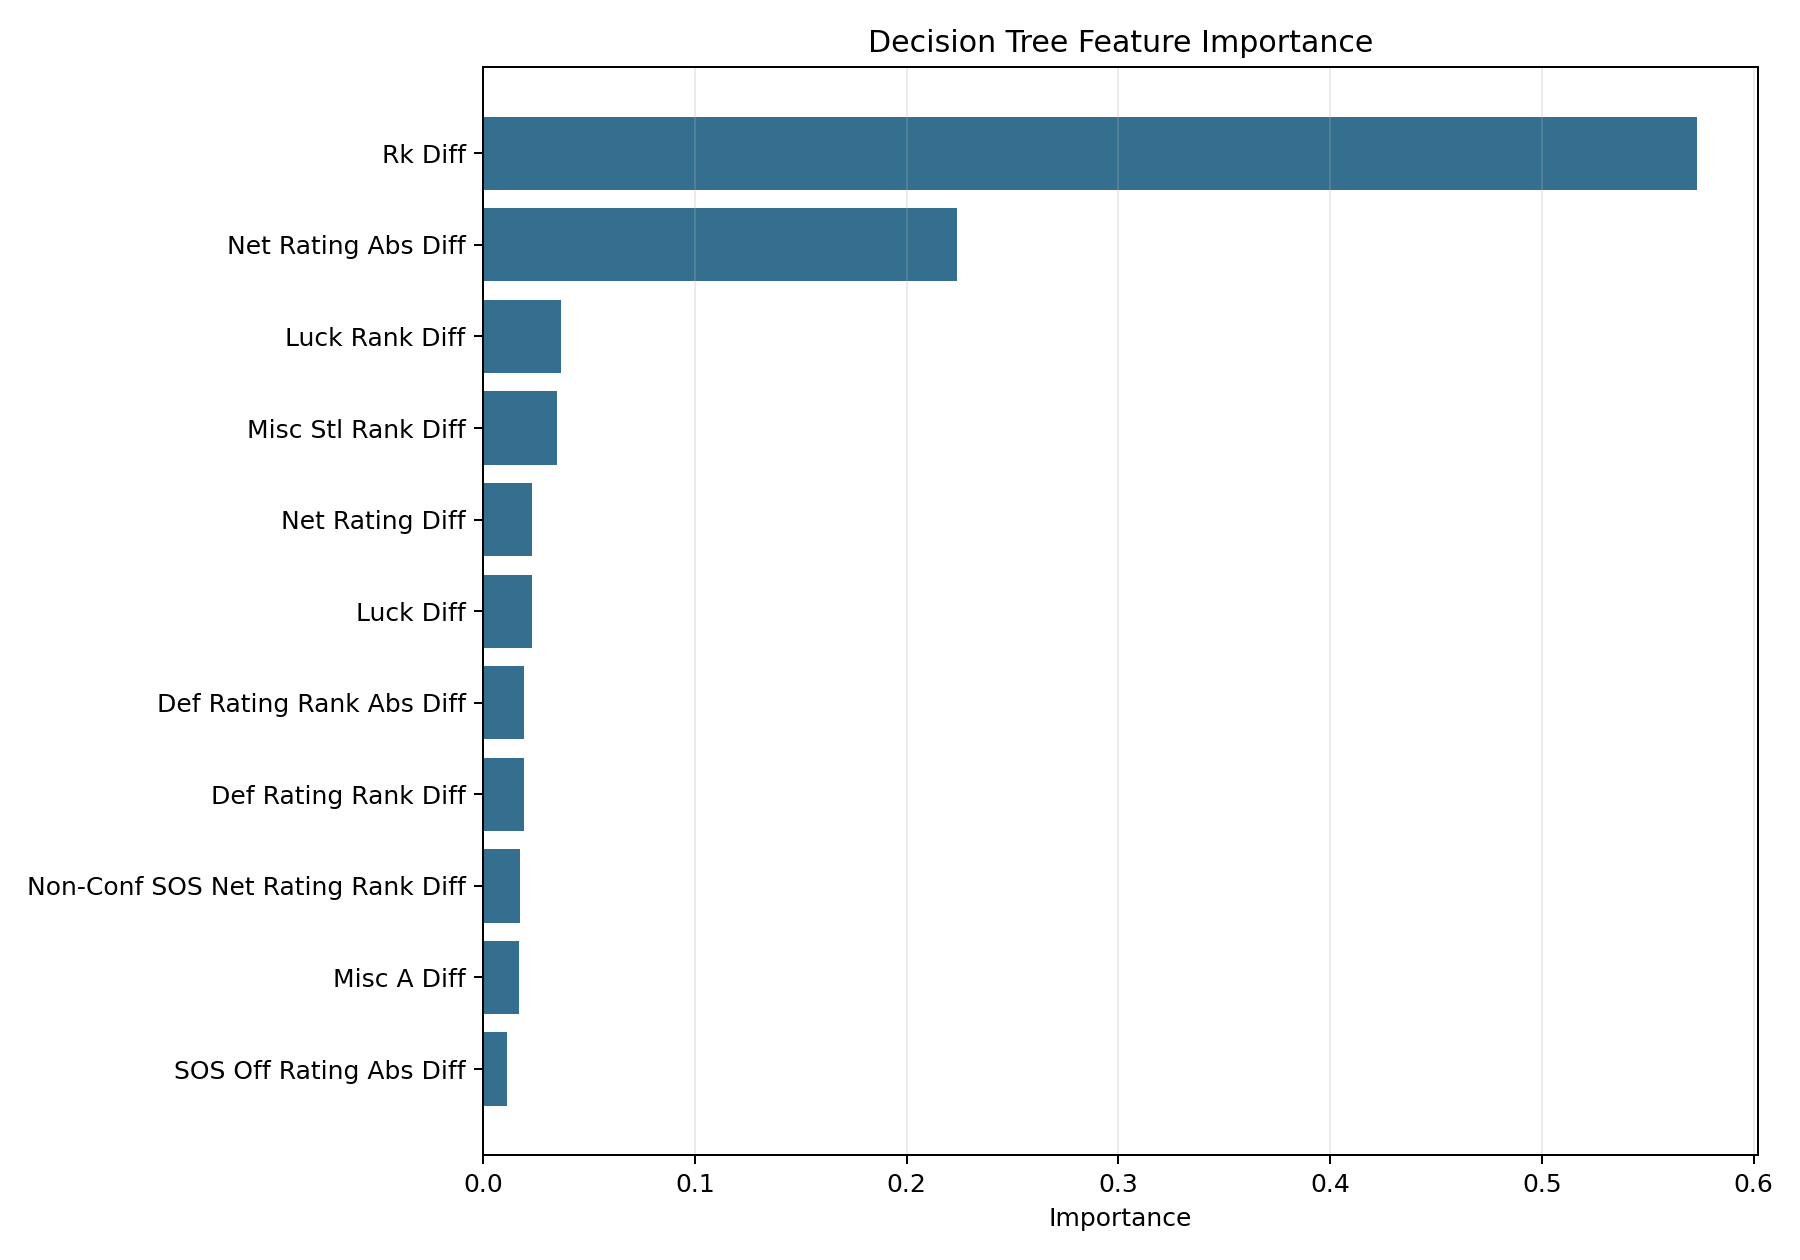

In [13]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'feature_importance.png')))

### Other Model Diagnostics

Round accuracy shows where the model held up or struggled. The confidence chart compares how sure the model was with the actual game margin.

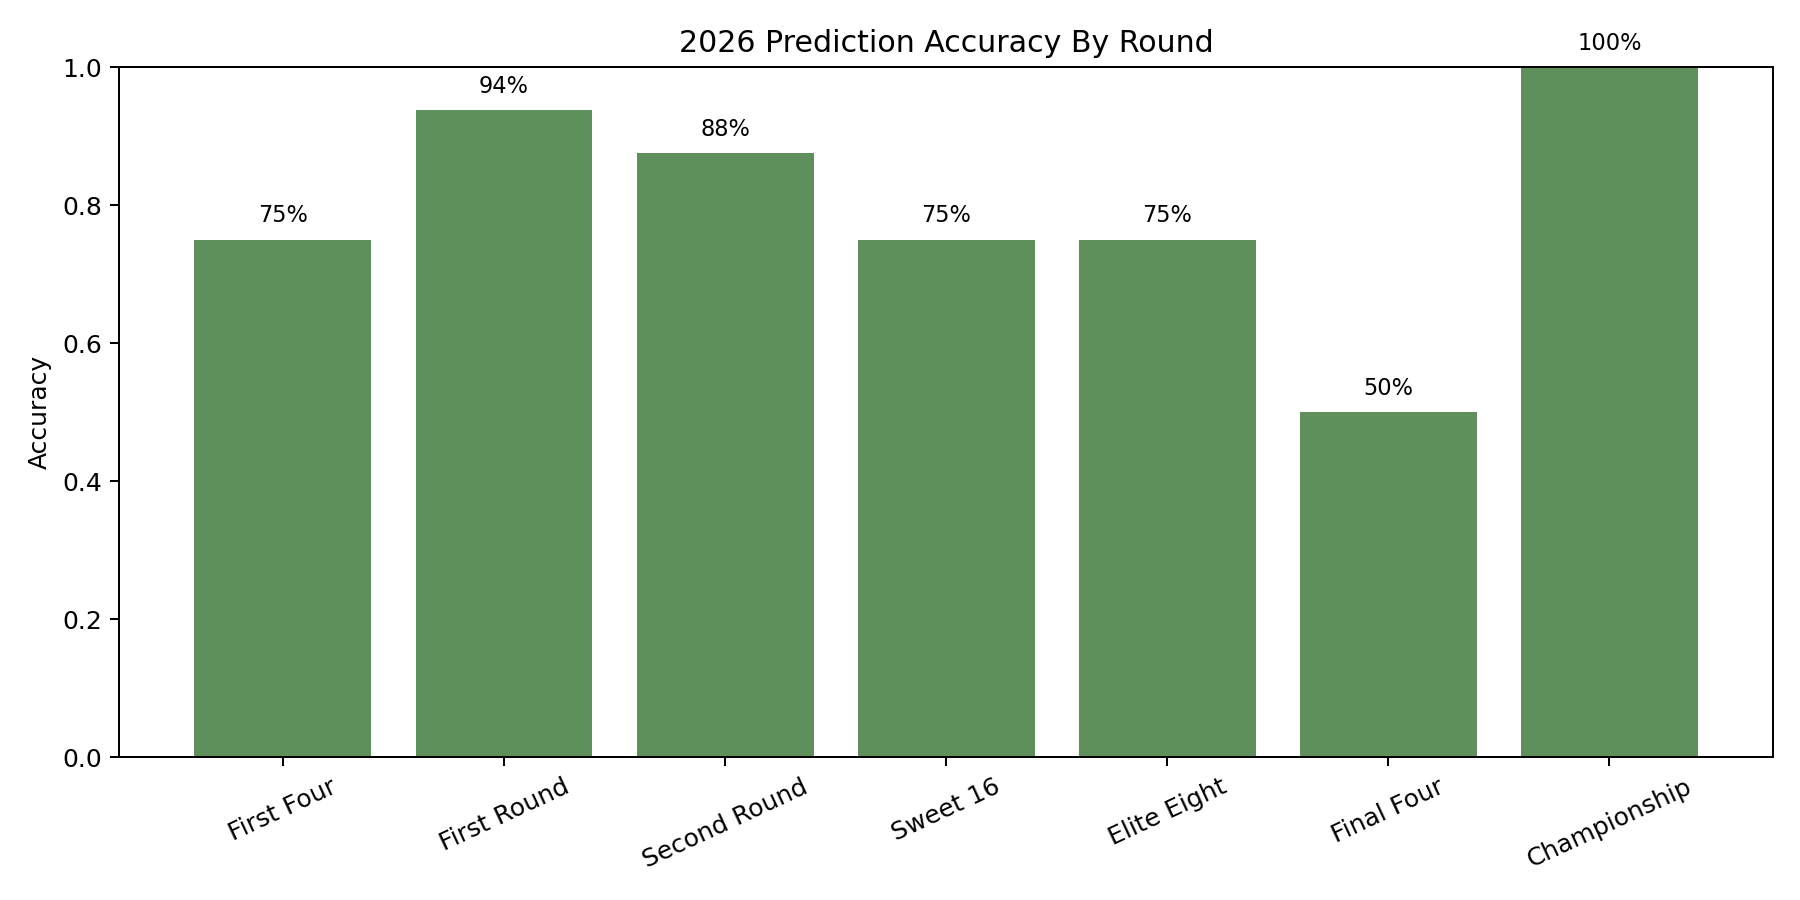

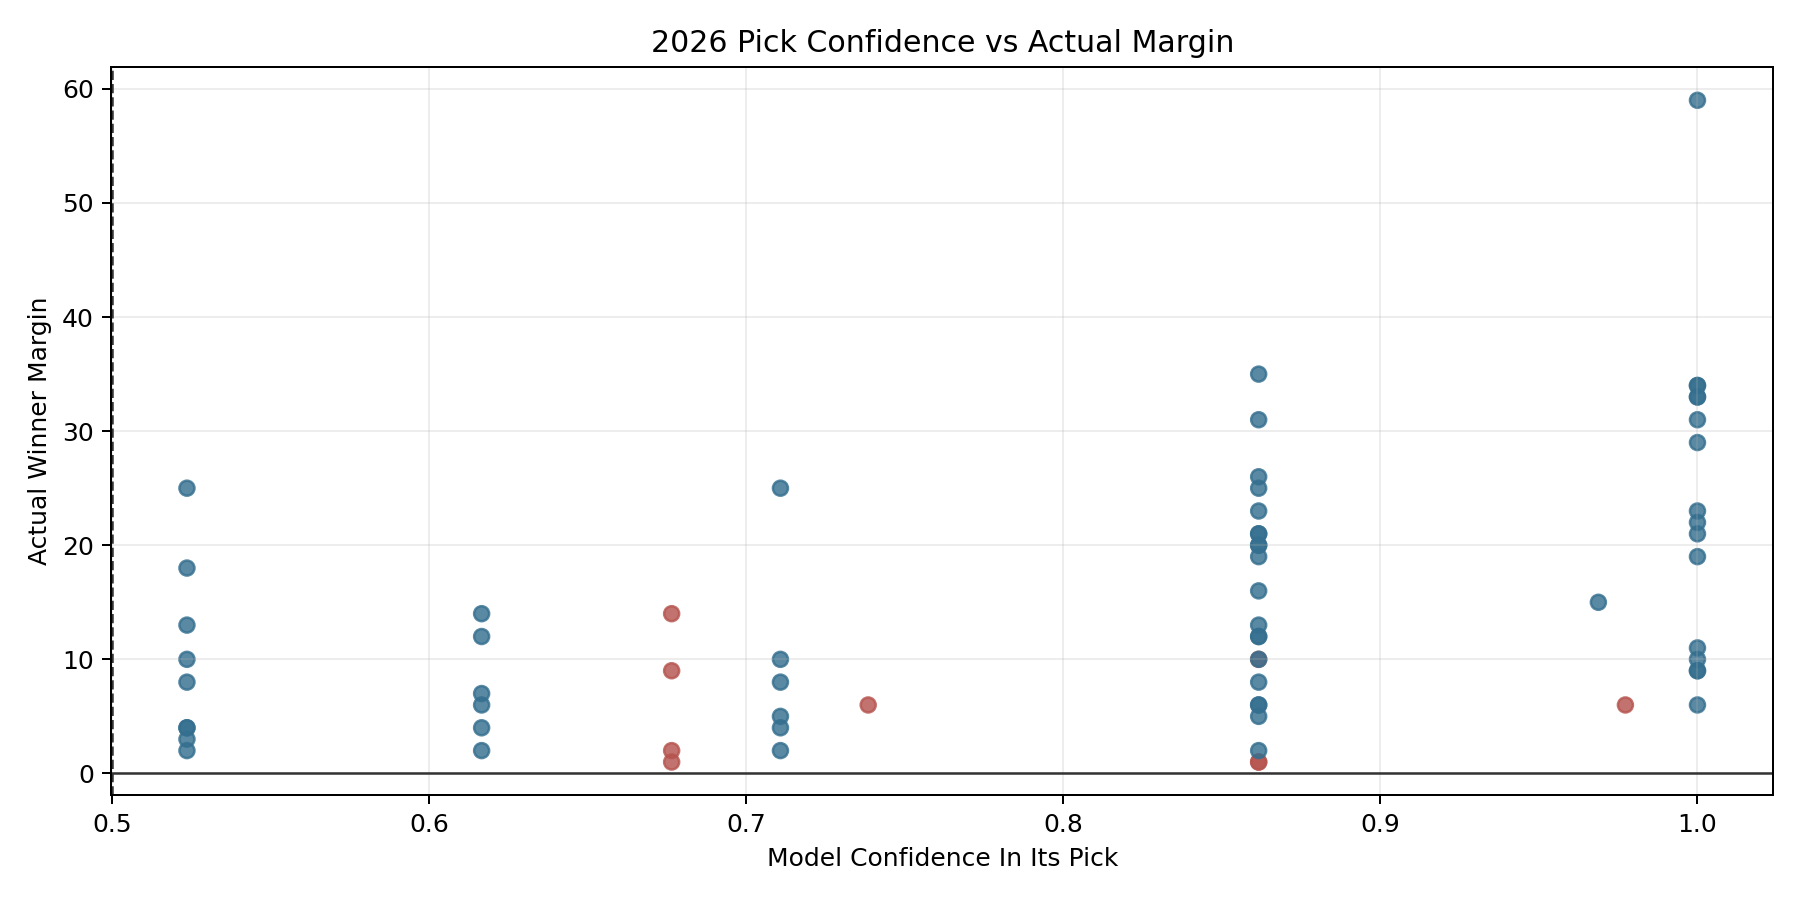

In [14]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / '2026_accuracy_by_round.png')))
display(Image(filename=str(PROJECT_ROOT / 'reports' / '2026_prediction_confidence.png')))

### 2026 Bracket Diagram With Model Picks

The HTML bracket has one card per played matchup. Blue cards are correct picks, red cards are misses. Each card includes the model pick, confidence, top matchup gaps, and the decision-tree path that explains the pick.

In [15]:
display(IFrame(src=str(PROJECT_ROOT / 'reports' / '2026_bracket_predictions.html'), width='100%', height=900))

### Matchup-Level Explanations

Use this table when you want the plain-text reason for a pick without opening the bracket diagram.

In [16]:
explanations_2026 = pd.read_csv(PROJECT_ROOT / 'reports' / '2026_prediction_explanations.csv')
explanations_2026[[
    'round',
    'matchup',
    'predicted_winner',
    'predicted_winner_probability',
    'prediction_correct',
    'top_matchup_drivers',
    'decision_tree_rules',
]].head(20)

,round,matchup,predicted_winner,predicted_winner_probability,prediction_correct,top_matchup_drivers,decision_tree_rules
0,First Four,Howard vs UMBC,Howard,0.523605,True,Rk Diff +9.00; Non-Conf SOS Net Rating Diff +5...,Rk Diff > -2.50 (value 9.00) | Net Rating Abs ...
1,First Four,Texas vs NC State,Texas,0.616541,True,Non-Conf SOS Net Rating Diff -10.82; Rk Diff -...,Rk Diff <= -2.50 (value -6.00) | Net Rating Ab...
2,First Four,Prairie View A&M vs Lehigh,Prairie View A&M,0.616541,True,Rk Diff -11.00; Non-Conf SOS Net Rating Diff +...,Rk Diff <= -2.50 (value -11.00) | Net Rating A...
3,First Four,Miami OH vs SMU,SMU,0.861607,False,Rk Diff -42.00; SOS Net Rating Diff +14.79; No...,Rk Diff > -2.50 (value 42.00) | Net Rating Abs...
4,First Round,TCU vs Ohio State,Ohio State,0.676471,False,Rk Diff -19.00; Off Rating Diff +9.00; Non-Con...,Rk Diff > -2.50 (value 19.00) | Net Rating Abs...
5,First Round,Nebraska vs Troy,Nebraska,1.000000,True,Rk Diff -134.00; Net Rating Diff +25.42; Def R...,Rk Diff <= -2.50 (value -134.00) | Net Rating ...
6,First Round,Louisville vs South Florida,Louisville,0.710784,True,Rk Diff -28.00; SOS Net Rating Diff +8.83; Net...,Rk Diff <= -2.50 (value -28.00) | Net Rating A...
7,First Round,High Point vs Wisconsin,Wisconsin,0.861607,False,Rk Diff -62.00; SOS Net Rating Diff +21.44; Ne...,Rk Diff > -2.50 (value 62.00) | Net Rating Abs...
8,First Round,Duke vs Siena,Duke,1.000000,True,Rk Diff -177.00; Net Rating Diff +38.41; SOS N...,Rk Diff <= -2.50 (value -177.00) | Net Rating ...
9,First Round,Vanderbilt vs McNeese,Vanderbilt,0.861607,True,Rk Diff -54.00; SOS Net Rating Diff +15.96; Ne...,Rk Diff <= -2.50 (value -54.00) | Net Rating A...


## 9. Trustworthy Four Factors + Misc Importance Analysis

This is the primary analysis. It:

- computes Four Factors and misc rates only from regular-season box scores;
- excludes seed, KenPom rank, net rating, luck, and adjusted efficiency from model inputs;
- uses one deterministic row per tournament game;
- compares logistic regression, a decision tree, random forest, and gradient boosting;
- calibrates probabilities using earlier-season out-of-fold predictions;
- validates on future seasons and measures permutation importance stability by season;
- engineers strength-vs-strength, strength-vs-weakness, balance, shooting-leverage, and ball-security features.

In [17]:
from src.build_pretournament_features import main as build_pretournament_features
from src.analyze_factor_importance import main as run_factor_importance_analysis

build_pretournament_features()
run_factor_importance_analysis()

factor_metrics = json.loads((PROJECT_ROOT / 'reports' / 'factor_model_metrics.json').read_text())
factor_comparison = pd.read_csv(PROJECT_ROOT / 'reports' / 'factor_model_comparison.csv')

print('Selected model:', factor_metrics['selected_model'])
print('Pre-tournament timing:', factor_metrics['snapshot_status'])
print('Importance gate passed:', factor_metrics['trustworthiness']['importance_gate_passed'])
factor_comparison

Wrote data/processed/pretournament_team_factors.csv with 7,255 team-seasons
Confirmed pre-tournament seasons: 2003-2023
Excluded incomplete seasons: {'2024': 100}


{
  "selected_model": "regularized_logistic",
  "metrics": {
    "raw_accuracy": 0.6433915211970075,
    "raw_brier": 0.2208480632092319,
    "raw_log_loss": 0.6343500725290288,
    "raw_roc_auc": 0.7065028110851286,
    "calibrated_accuracy": 0.6408977556109726,
    "calibrated_brier": 0.21730892643296115,
    "calibrated_log_loss": 0.6239428246363556,
    "calibrated_roc_auc": 0.7065028110851286
  },
  "trustworthiness": {
    "importance_gate_passed": true,
    "selection_accuracy_auc_gate_passed": true,
    "accuracy_wilson_95": [
      0.592809358133265,
      0.6863121550709117
    ],
    "stable_features_in_top_15": 15,
    "minimum_stability_definition": "positive permutation importance in at least 60% of held-out seasons"
  }
}
Wrote reports/factor_model_feature_importance.png
Wrote reports/factor_model_group_importance.png
Selected model: regularized_logistic
Pre-tournament timing: confirmed_pre_tournament
Importance gate passed: True


,model,raw_accuracy,raw_brier,raw_log_loss,raw_roc_auc,calibrated_accuracy,calibrated_brier,calibrated_log_loss,calibrated_roc_auc
0,regularized_logistic,0.643392,0.220848,0.634350,0.706503,0.640898,0.217309,0.623943,0.706503
1,random_forest,0.613466,0.223715,0.637377,0.684760,0.610973,0.223454,0.636771,0.684760
2,hist_gradient_boosting,0.645885,0.234921,0.682627,0.687547,0.648379,0.224497,0.640258,0.687547
3,decision_tree,0.561097,0.258382,0.968488,0.603886,0.561097,0.241486,0.677485,0.603886


### Feature Importance

Bars are held-out permutation importance: the increase in log loss when a feature is shuffled within each validation season. Whiskers show uncertainty across seasons and repeated shuffles. Larger positive values mean the model relied more on that feature.

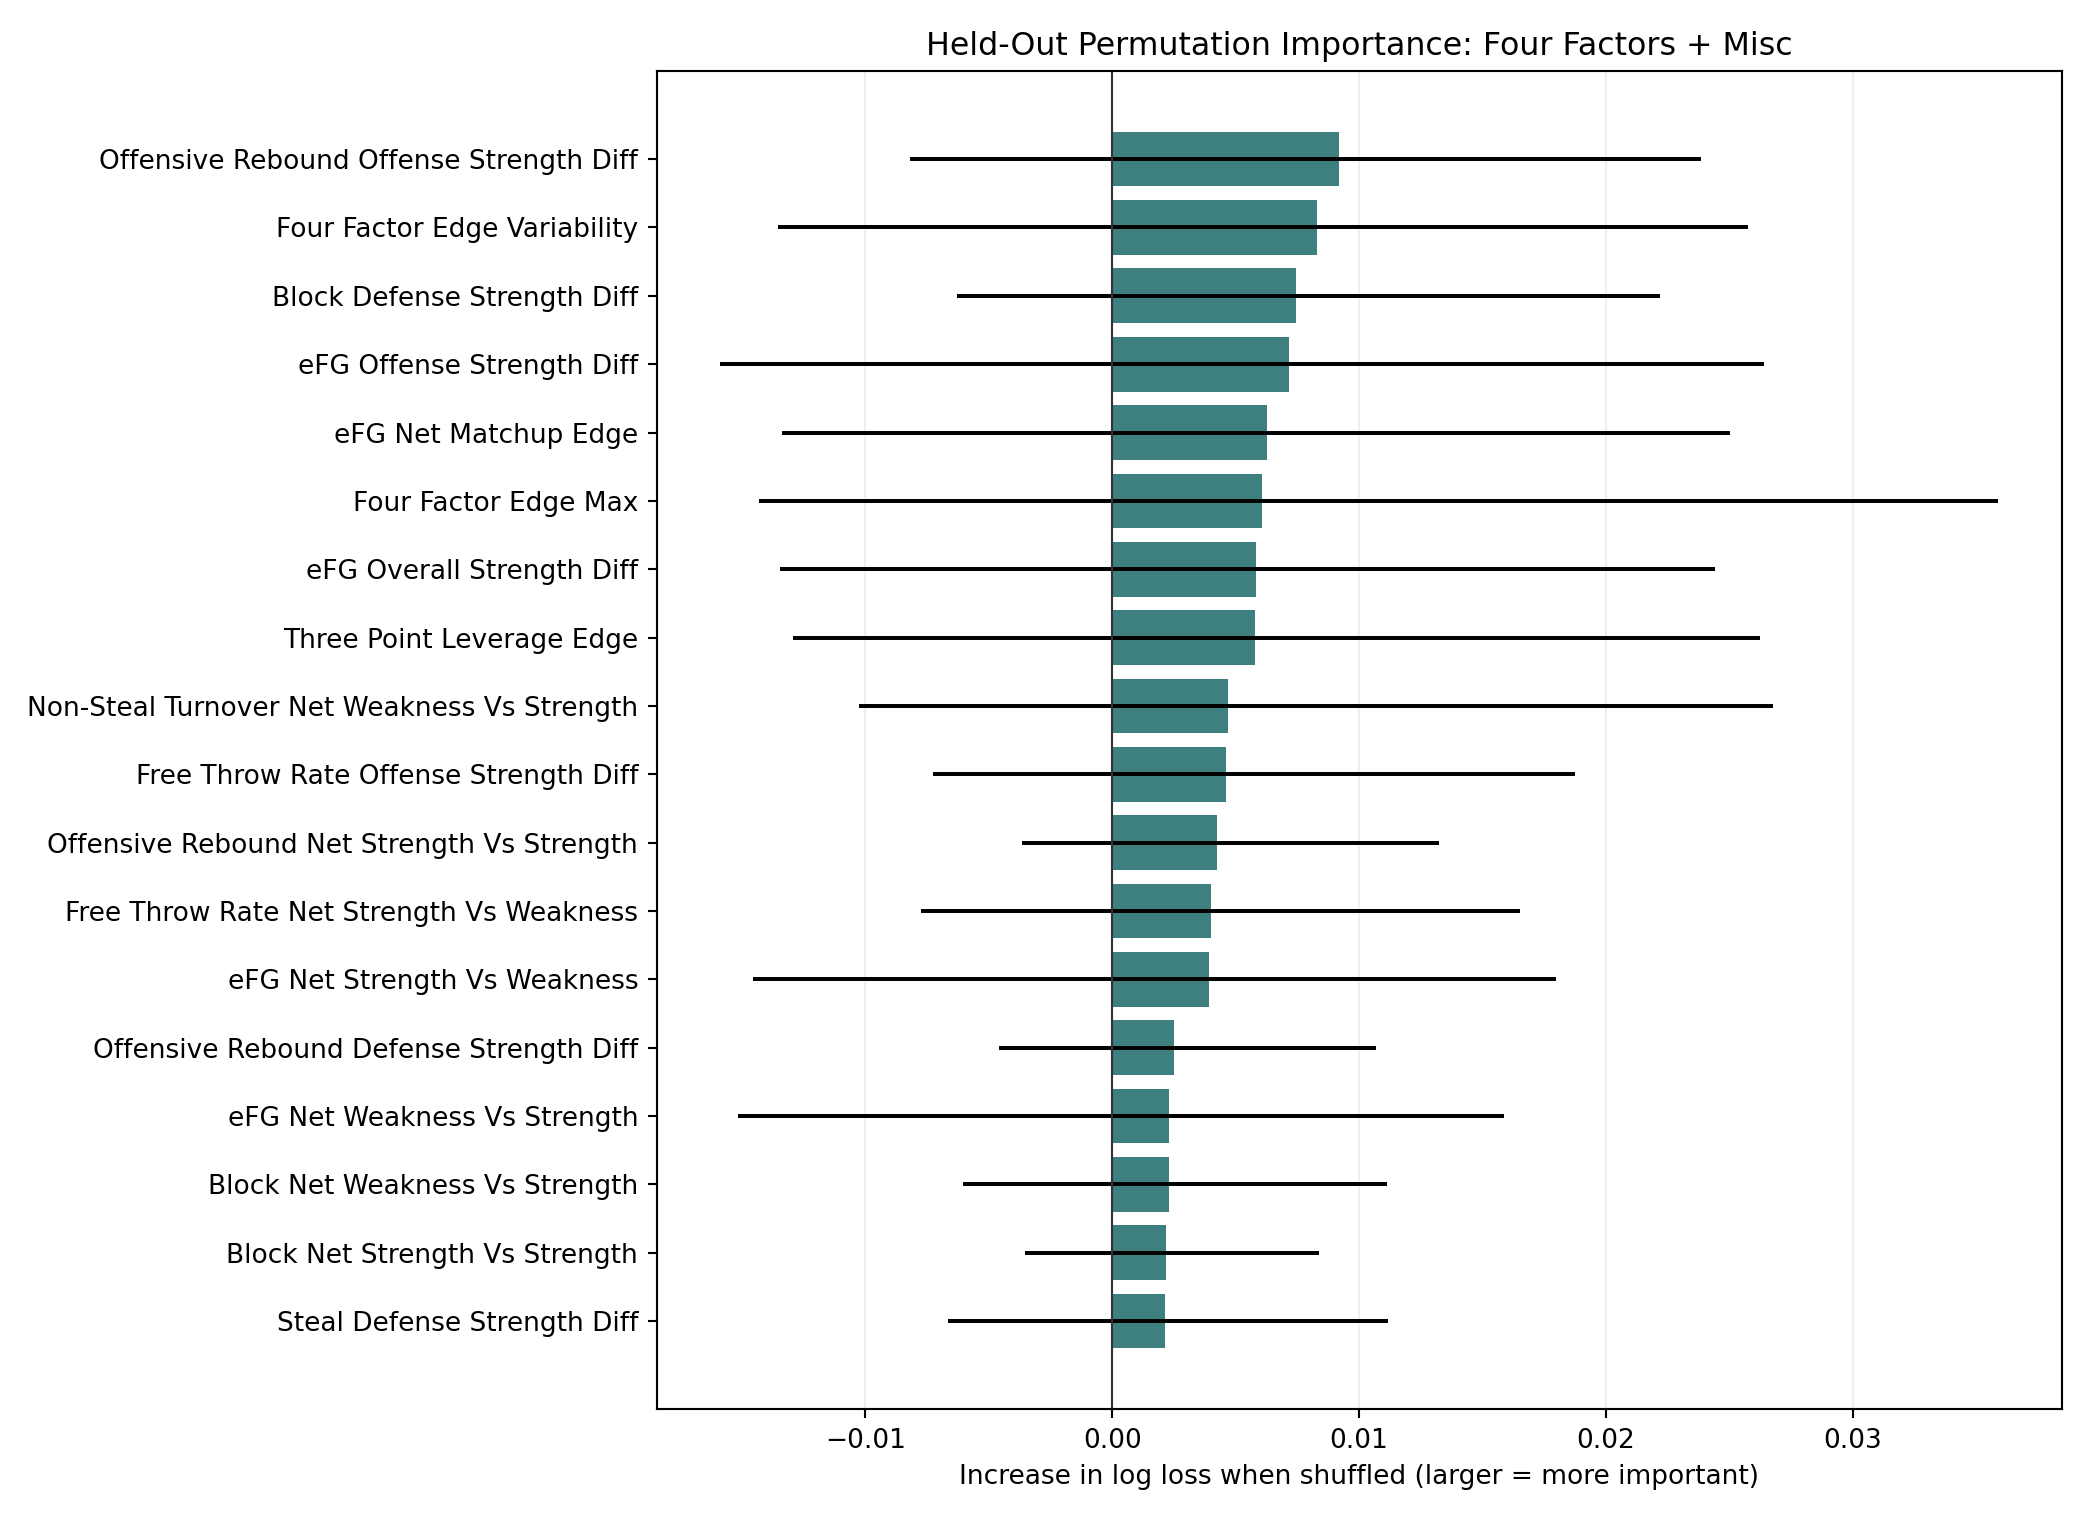

In [18]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_model_feature_importance.png')))

### Grouped Factor Importance

Correlated engineered features split credit. This grouped chart shuffles each basketball concept as a block and shows the range across all four model families.

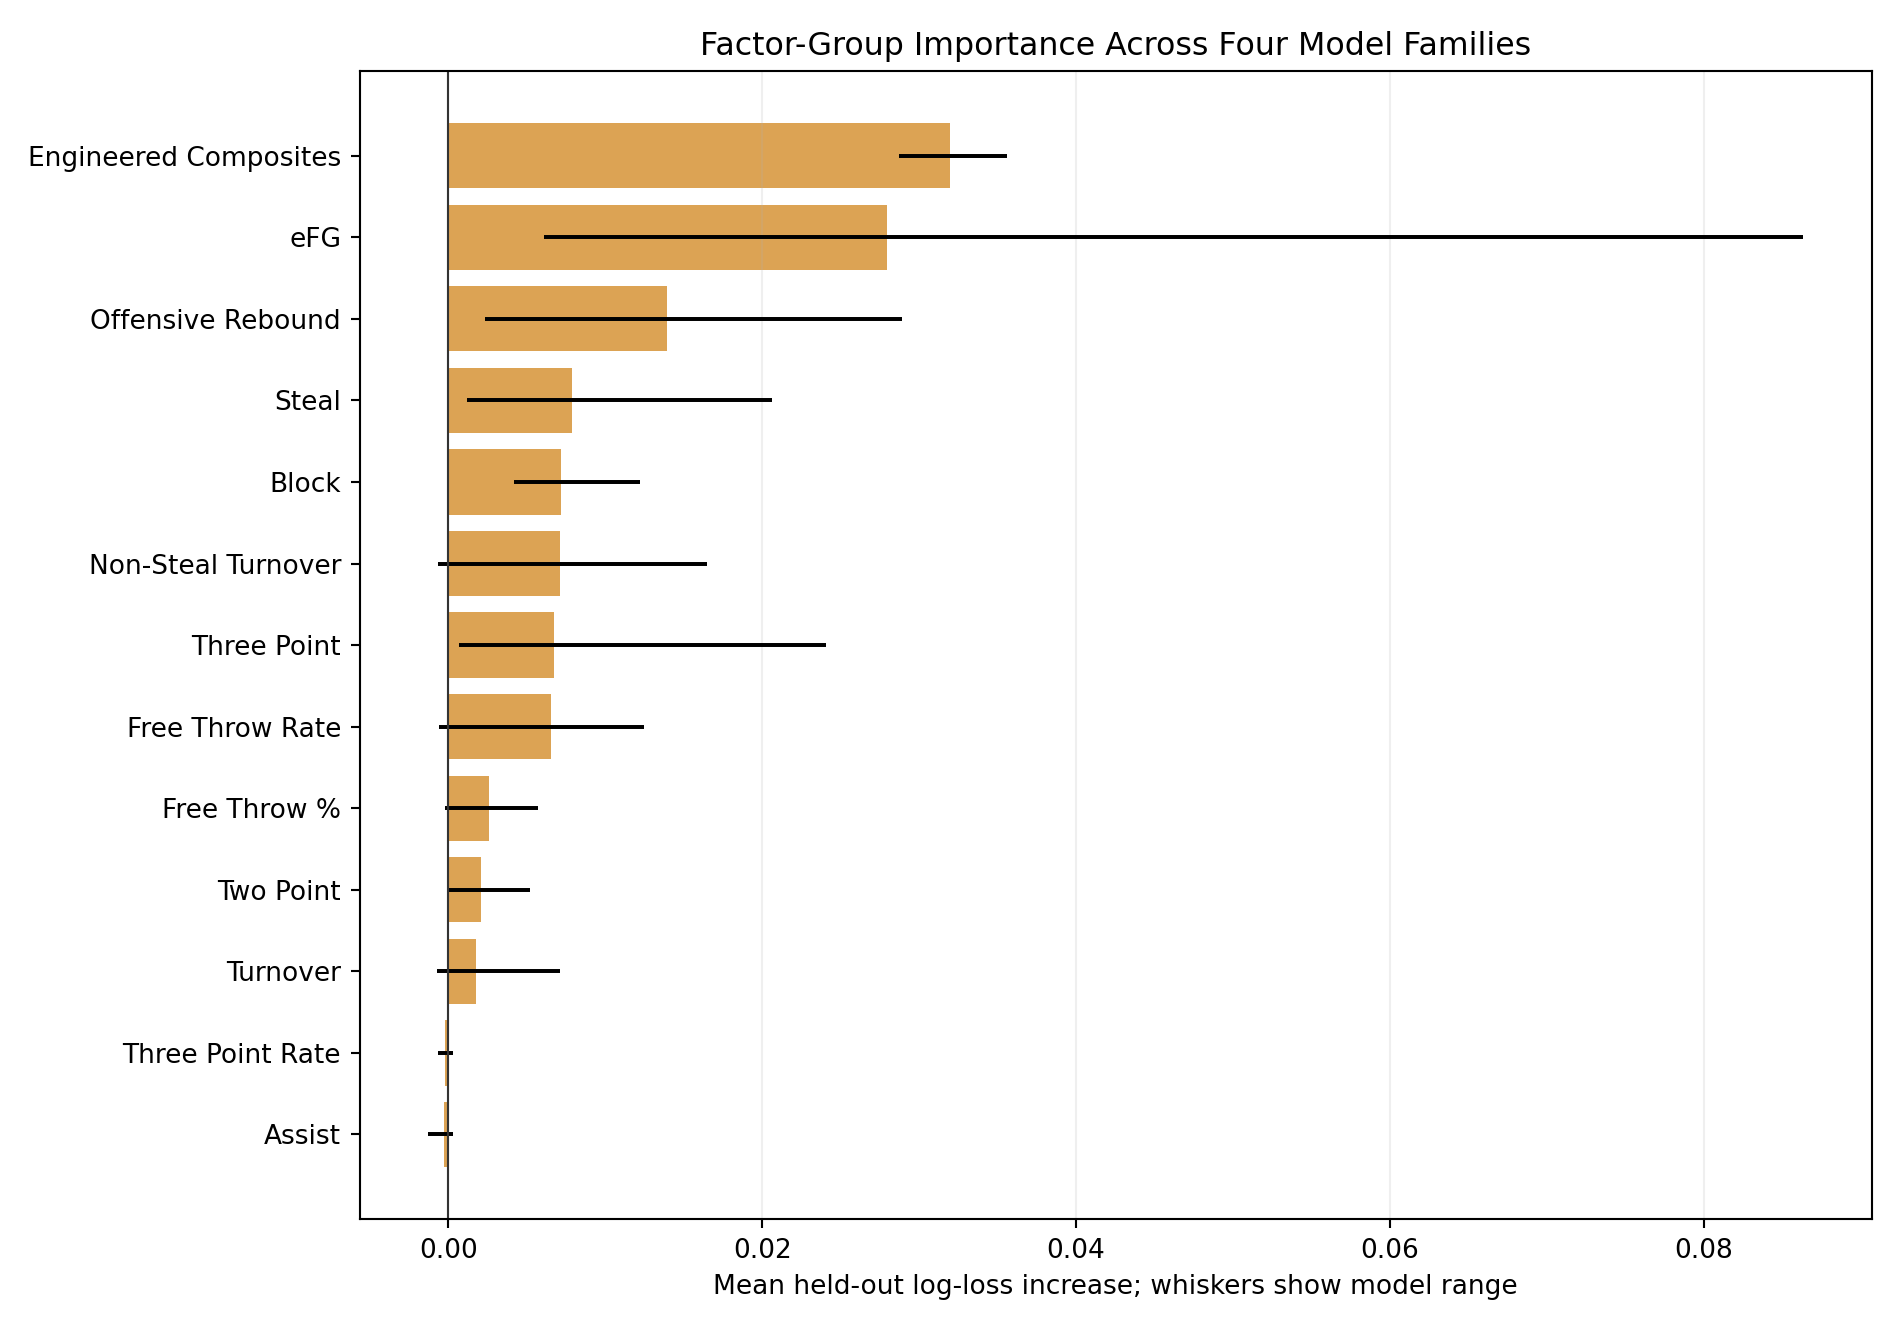

In [19]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_model_group_importance.png')))

### Model Comparison And Calibration

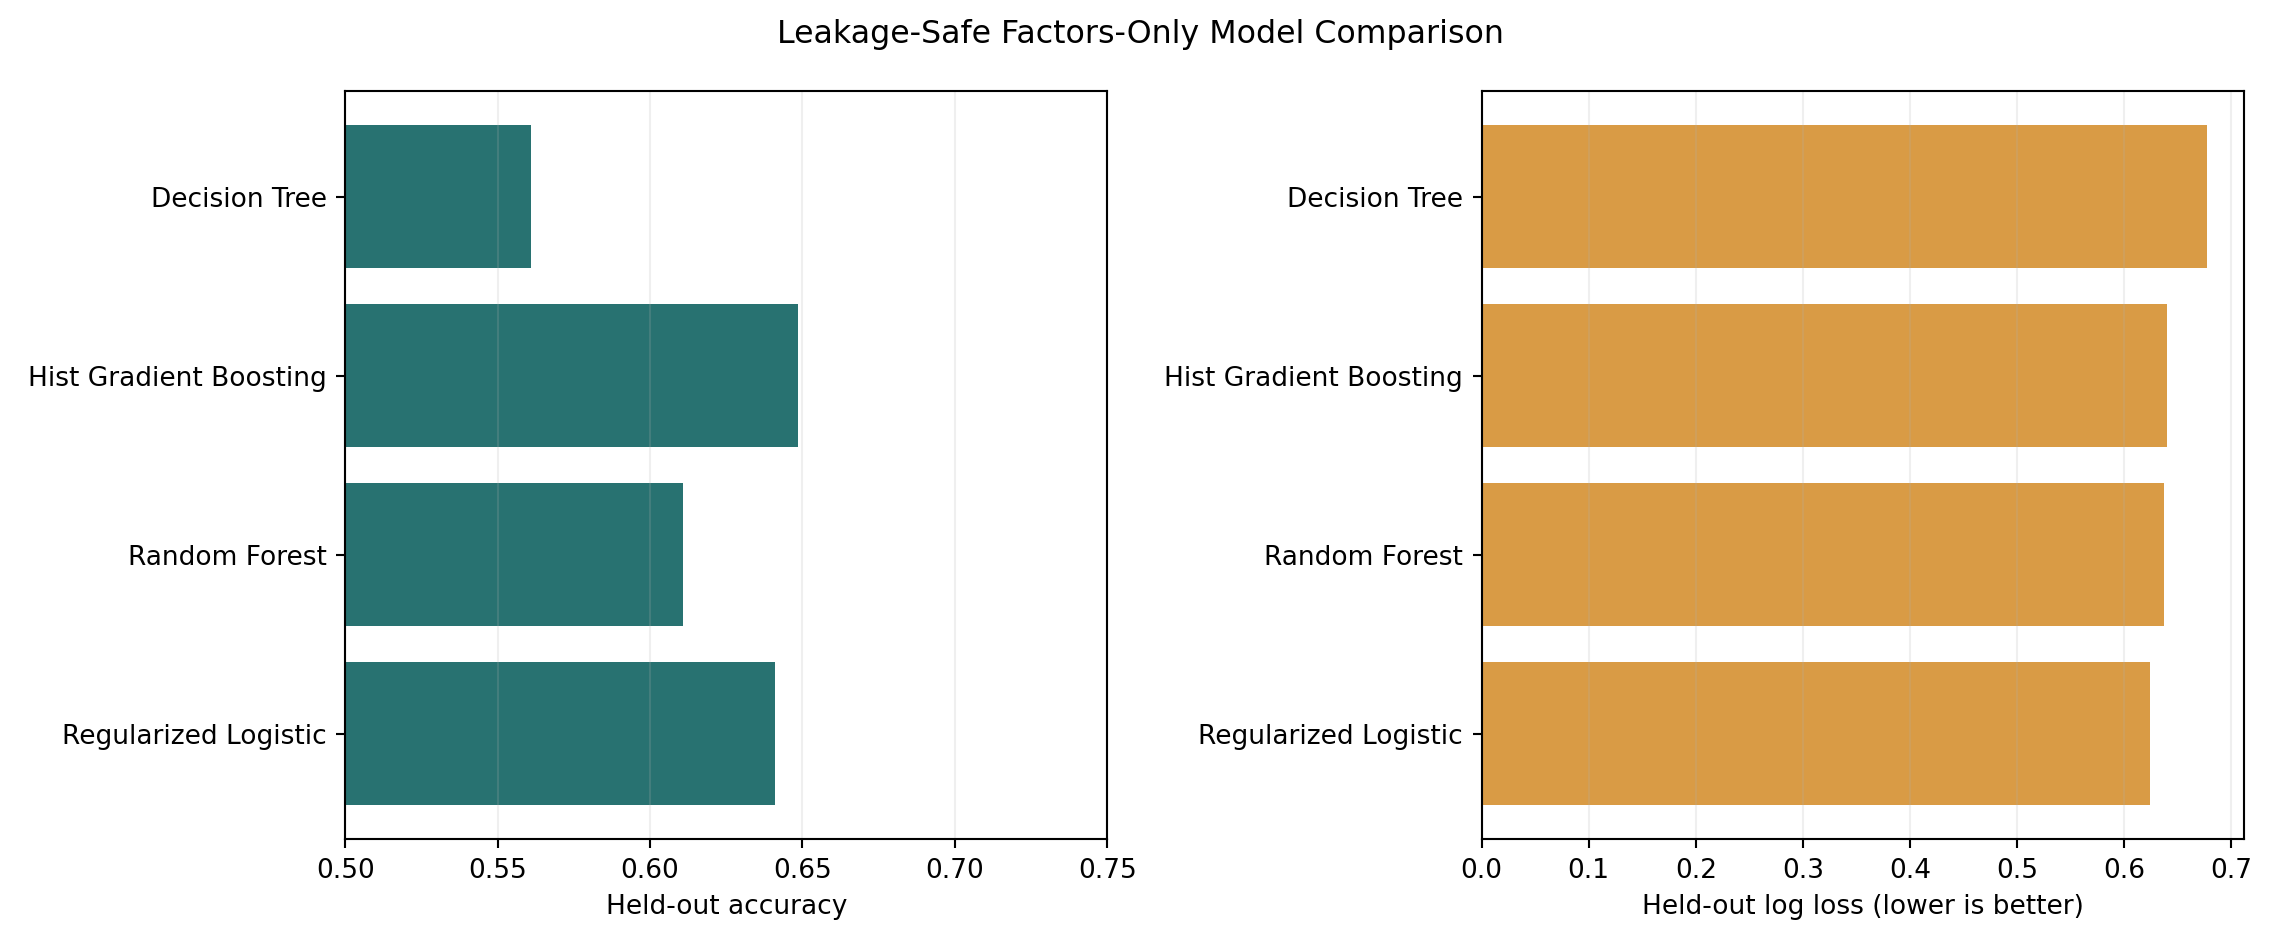

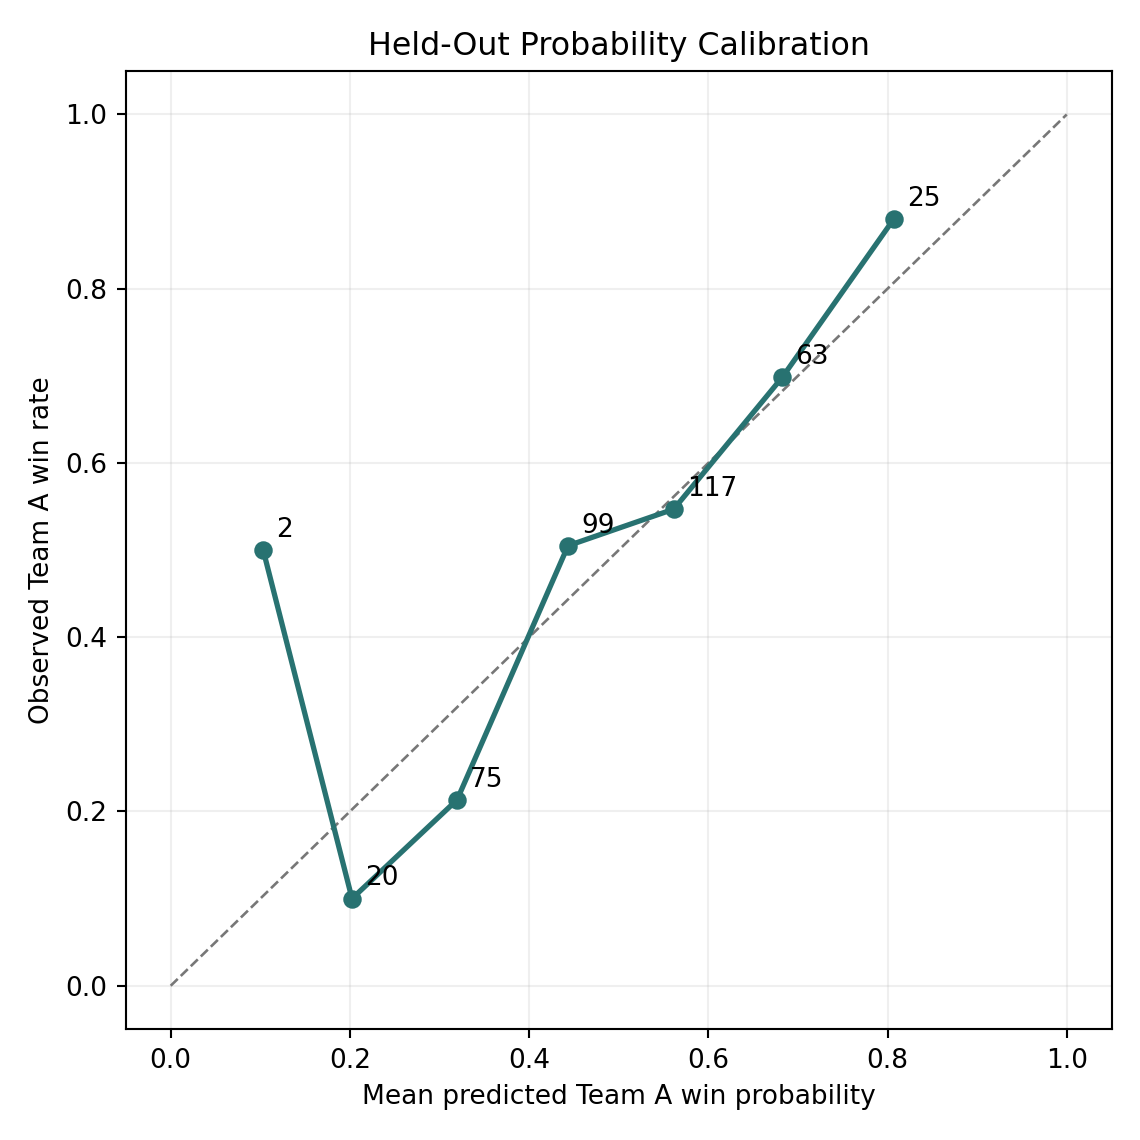

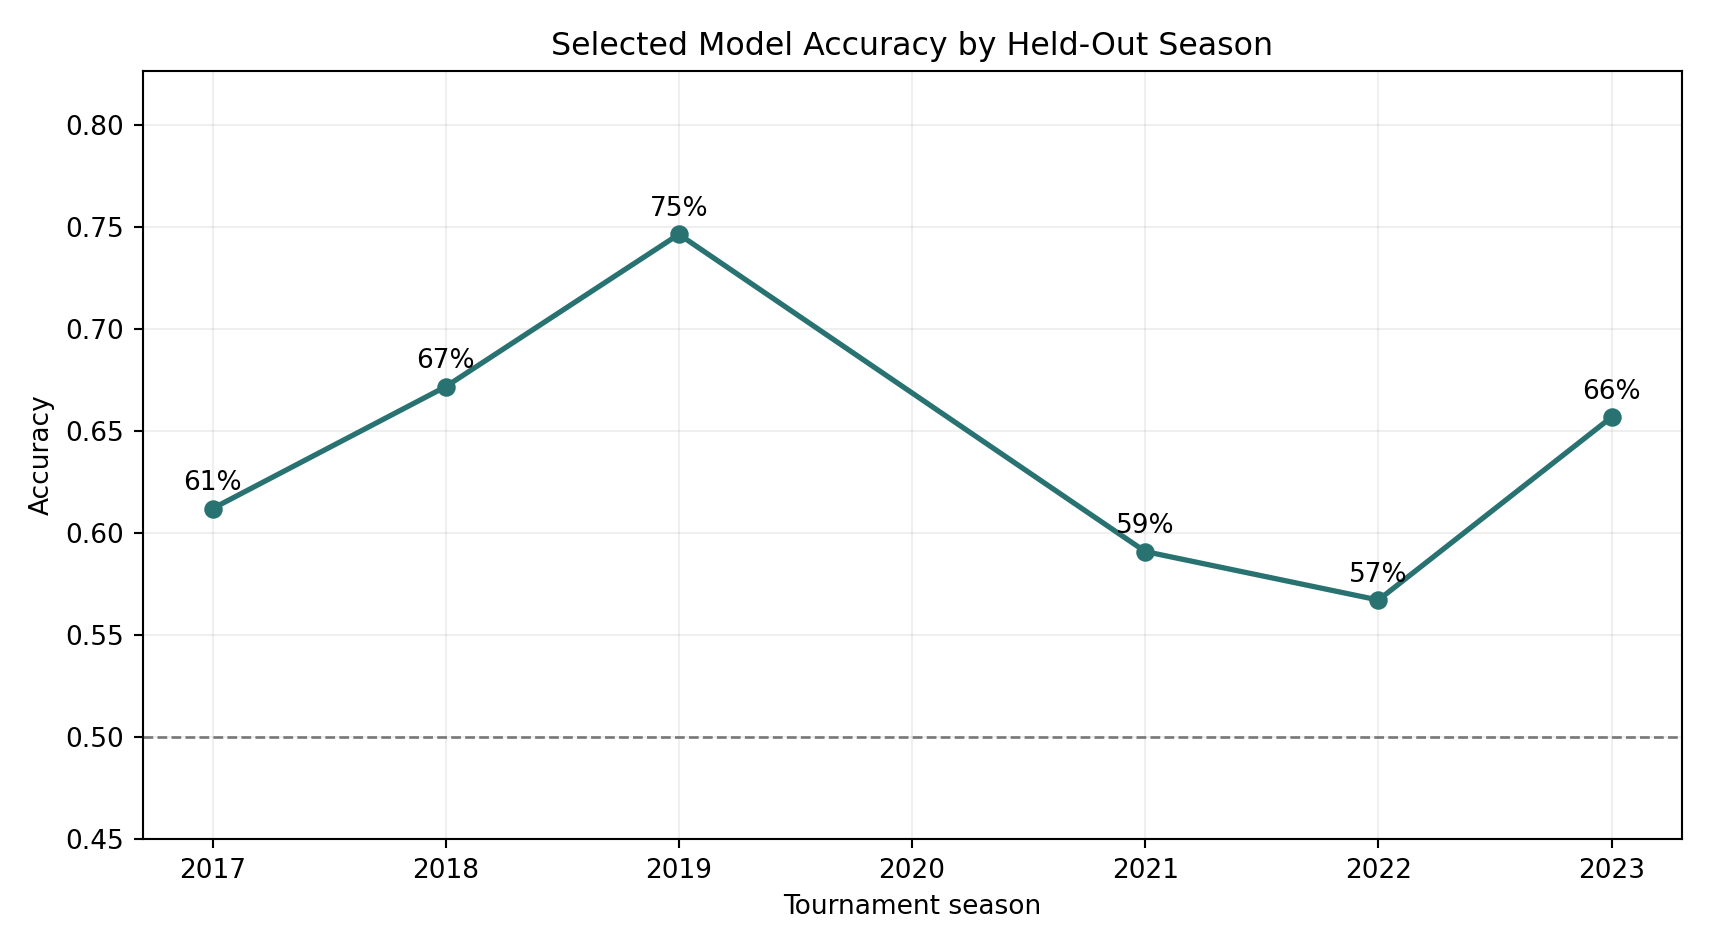

In [20]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_model_comparison.png')))
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_model_calibration.png')))
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_model_accuracy_by_year.png')))

### Strength Matchup Quadrants

These held-out descriptive rates compare strong and weak offenses against strong and weak defenses. Cells with fewer than 10 games are suppressed rather than over-interpreted.

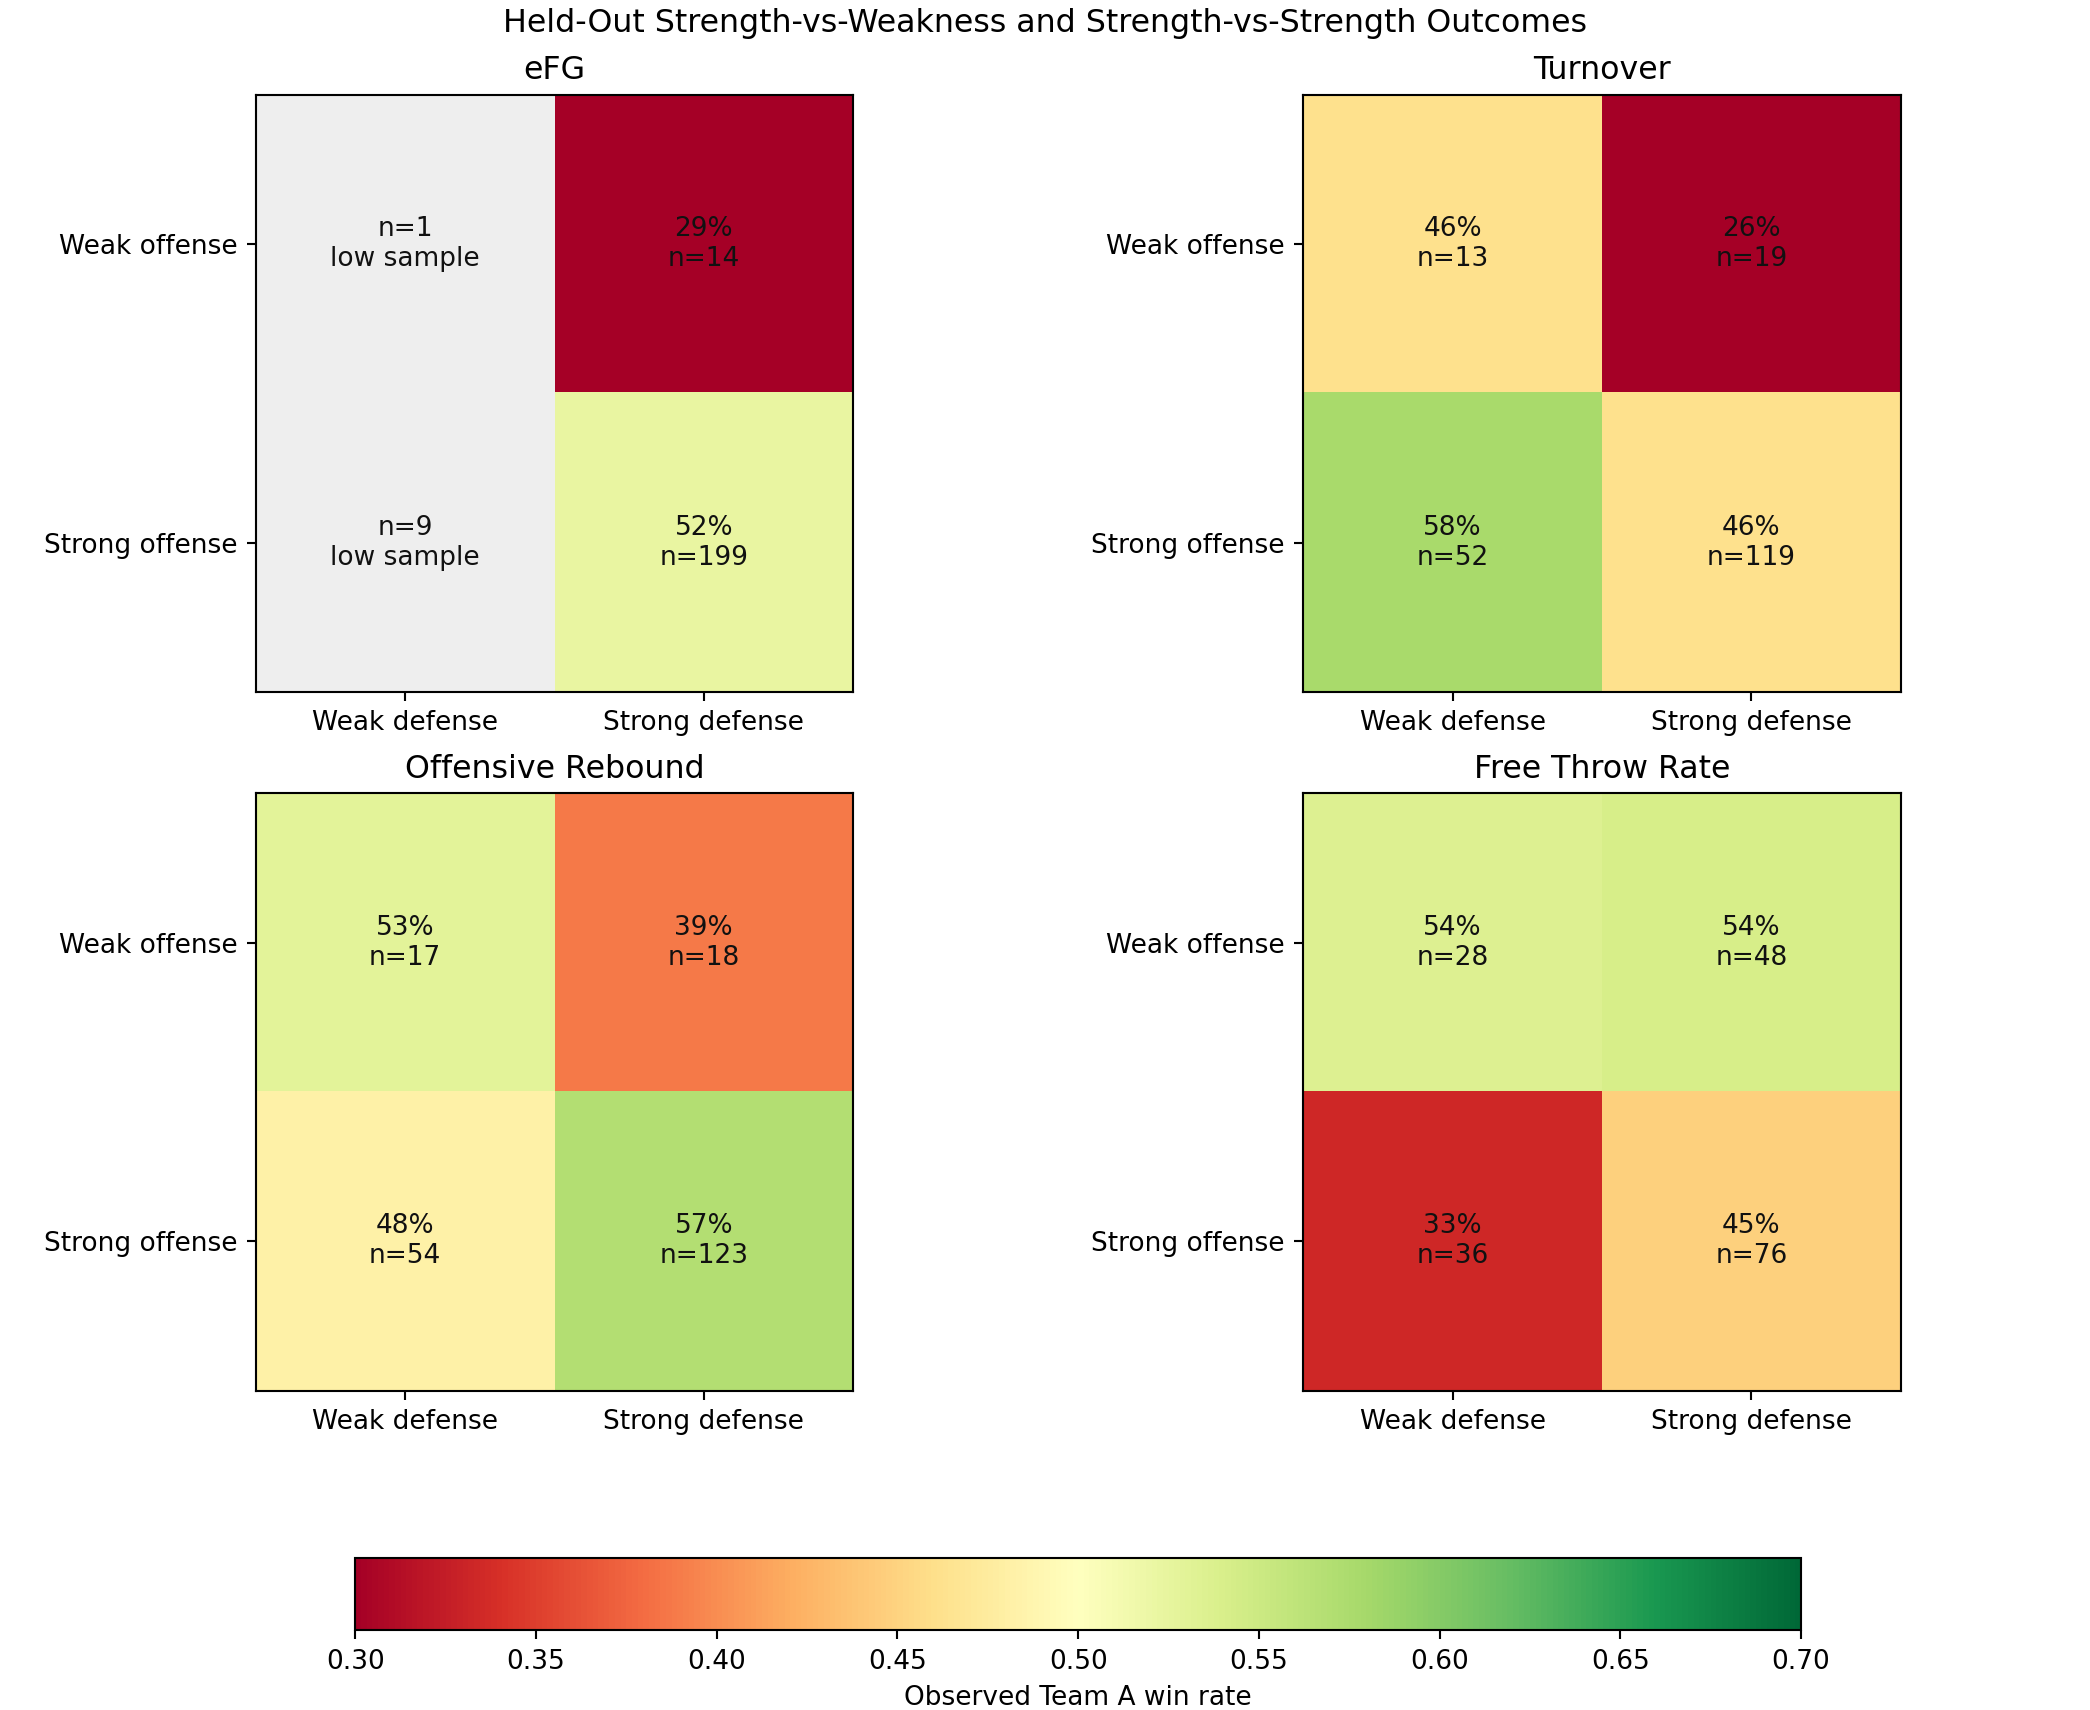

In [21]:
display(Image(filename=str(PROJECT_ROOT / 'reports' / 'factor_matchup_quadrants.png')))

### Stable Features And Upset Diagnostic

Seeds are used only here to label actual upsets after predictions are made. They are never model features.

In [22]:
factor_top_features = pd.read_csv(PROJECT_ROOT / 'reports' / 'factor_model_top_features.csv')
factor_upsets = pd.read_csv(PROJECT_ROOT / 'reports' / 'factor_model_upset_analysis.csv')
factor_rolling = pd.read_csv(PROJECT_ROOT / 'reports' / 'factor_model_rolling_validation.csv')

display(factor_top_features.head(20))
display(factor_upsets)
factor_rolling[factor_rolling['model'].eq(factor_metrics['selected_model'])]

,feature,family,importance_mean,importance_std,importance_low,importance_high,positive_fraction,positive_season_fraction,rank
0,offensive_rebound_off_strength_diff,offensive_rebound,0.009204,0.008855,-0.008178,0.023833,0.833333,1.000000,1
1,four_factor_edge_std,engineered_composites,0.008290,0.010107,-0.013552,0.025749,0.816667,0.833333,2
2,block_def_strength_diff,block,0.007458,0.007200,-0.006283,0.022202,0.858333,1.000000,3
3,efg_off_strength_diff,efg,0.007172,0.011992,-0.015863,0.026403,0.716667,0.833333,4
4,efg_net_matchup_edge,efg,0.006279,0.010257,-0.013361,0.025035,0.741667,0.833333,5
5,four_factor_edge_max,engineered_composites,0.006084,0.013706,-0.014304,0.035863,0.641667,0.833333,6
6,efg_overall_strength_diff,efg,0.005829,0.009196,-0.013469,0.024421,0.766667,0.666667,7
7,three_point_leverage_edge,engineered_composites,0.005797,0.010584,-0.012934,0.026223,0.691667,0.833333,8
8,nonsteal_turnover_net_weakness_vs_strength,nonsteal_turnover,0.004672,0.008692,-0.010234,0.026771,0.700000,0.833333,9
9,free_throw_rate_off_strength_diff,free_throw_rate,0.004594,0.007094,-0.007249,0.018740,0.725000,1.000000,10


,segment,games,accuracy,mean_confidence
0,actual_upsets,113,0.362832,0.610767
1,favorite_wins,288,0.750000,0.637928
2,all_seeded_games,401,0.640898,0.630274


,model,season,games,accuracy,brier,log_loss,roc_auc
0,regularized_logistic,2017,67,0.611940,0.231511,0.653113,0.683036
1,regularized_logistic,2018,67,0.656716,0.215198,0.629202,0.722321
2,regularized_logistic,2019,67,0.716418,0.190849,0.556491,0.800000
3,regularized_logistic,2021,66,0.590909,0.225546,0.642643,0.678704
4,regularized_logistic,2022,67,0.552239,0.253357,0.726119,0.643376
5,regularized_logistic,2023,67,0.597015,0.207811,0.593260,0.704505


## 10. Save Legacy Benchmark Model, Predictions, And Metrics

In [23]:
valid_meta = meta.loc[valid_mask].copy()
valid_meta['pred_team_a_win_prob'] = model.predict_proba(x.loc[valid_mask])[:, 1]
valid_meta['pred_team_a_win'] = (valid_meta['pred_team_a_win_prob'] >= 0.5).astype(int)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics['tree'] = tree_text
joblib.dump({'model': model, 'features': list(x.columns)}, MODEL_PATH)
valid_meta.to_csv(PREDICTIONS_PATH, index=False)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f'Wrote {MODEL_PATH}')
print(f'Wrote {PREDICTIONS_PATH}')
print(f'Wrote {METRICS_PATH}')
valid_meta.head()

Wrote /Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning/models/decision_tree_march_madness.joblib
Wrote /Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning/reports/validation_predictions.csv
Wrote /Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning/reports/metrics.json


,season,team_a,team_b,actual_team_a_win,pred_team_a_win_prob,pred_team_a_win
1658,2017,Kansas St,Wake Forest,1,0.710784,1
1659,2017,Wake Forest,Kansas St,0,0.523605,1
1660,2017,USC,Providence,1,0.710784,1
1661,2017,Providence,USC,0,0.022727,0
1662,2017,Arizona,North Dakota,1,1.000000,1
